# 03 – Evaluación Comparativa de Modelos
**Proyecto:** Sistema de Ventas Retail  
**Asignatura:** SCY1101 – Programación para la Ciencia de Datos

---

## Objetivos
1. Evaluar en profundidad los modelos entrenados en el notebook 02.
2. Aplicar validación cruzada con múltiples métricas.
3. Comparar modelos de clasificación con curvas ROC y matrices de confusión.
4. Comparar modelos de regresión con gráficos de residuos y predicho vs real.
5. Interpretar resultados y seleccionar los mejores modelos para optimización.
---


## 1. Importaciones

In [2]:
import sys, os, warnings, joblib
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold,
    cross_validate, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.neighbors import KNeighborsClassifier

from data_preprocessing import pipeline_completo

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
SEED = 42
np.random.seed(SEED)
THRESHOLD = 0.3  # threshold ajustado para clasificación desbalanceada

print("✓ Librerías importadas correctamente")


✓ Librerías importadas correctamente


## 2. Carga y Preparación del Dataset

In [3]:
df_ml, *_ = pipeline_completo()

# Limpieza final (igual que notebook 02)
df_ml = df_ml[df_ml['total_venta'] > 0].copy()
df_ml['canal_venta'] = df_ml['canal_venta'].fillna(df_ml['canal_venta'].mode()[0])
df_ml['precio_lista'] = df_ml.groupby('categoria')['precio_lista'].transform(
    lambda x: x.fillna(x.median()))
df_ml['precio_lista'] = df_ml['precio_lista'].fillna(df_ml['precio_lista'].median())
df_ml['descuento_relativo'] = (
    (df_ml['precio_lista'] - df_ml['precio_unitario']) / df_ml['precio_lista']
).clip(lower=0).fillna(0)

FEATURES_NUM = ['cantidad', 'precio_unitario', 'mes', 'dia_semana',
                'trimestre', 'descuento_relativo', 'precio_lista']
FEATURES_CAT = ['metodo_pago', 'canal_venta', 'segmento',
                'categoria', 'region', 'proveedor']
FEATURES = FEATURES_NUM + FEATURES_CAT

X = df_ml[FEATURES].copy()
y_clas = df_ml['tiene_devolucion'].copy()
y_reg  = np.log1p(df_ml['total_venta'].copy())

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clas, test_size=0.2, random_state=SEED, stratify=y_clas)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED)

print(f"Dataset: {df_ml.shape} | Train: {X_train_c.shape} | Test: {X_test_c.shape}")


Dataset: (778, 19) | Train: (622, 13) | Test: (156, 13)


## 3. Definición y Entrenamiento de Modelos

In [4]:
# Clasificación
pipelines_clas = {
    'Logistic Regression': Pipeline([('prep', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=SEED, C=1.0))]),
    'Decision Tree': Pipeline([('prep', preprocessor),
        ('model', DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                          min_samples_leaf=10, random_state=SEED))]),
    'Random Forest': Pipeline([('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                          max_depth=8, min_samples_leaf=5,
                                          random_state=SEED, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                              learning_rate=0.05, subsample=0.8,
                                              random_state=SEED))]),
    'KNN': Pipeline([('prep', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=11, weights='distance'))]),
}

# Regresión
pipelines_reg = {
    'Linear Regression': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'Ridge': Pipeline([('prep', preprocessor),
                       ('model', Ridge(alpha=10.0, random_state=SEED))]),
    'Lasso': Pipeline([('prep', preprocessor),
                       ('model', Lasso(alpha=0.01, max_iter=5000, random_state=SEED))]),
    'Random Forest': Pipeline([('prep', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=8,
                                         min_samples_leaf=5, random_state=SEED, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                             learning_rate=0.05, subsample=0.8,
                                             random_state=SEED))]),
}

# Entrenar todos
for nombre, pipe in pipelines_clas.items():
    pipe.fit(X_train_c, y_train_c)
for nombre, pipe in pipelines_reg.items():
    pipe.fit(X_train_r, y_train_r)

print("✓ Todos los modelos entrenados")


✓ Todos los modelos entrenados


---
## 4. Validación Cruzada — Clasificación

Usamos `StratifiedKFold(5)` para mantener la proporción de clases en cada fold.  
Métricas evaluadas: **ROC-AUC, F1, Recall, Precision, Accuracy**.


In [5]:
cv_clas = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv_clas = {}

scoring_clas = {
    'roc_auc':   'roc_auc',
    'f1':        'f1',
    'recall':    'recall',
    'precision': 'precision',
    'accuracy':  'accuracy',
}

for nombre, pipe in pipelines_clas.items():
    cv_res = cross_validate(pipe, X_train_c, y_train_c,
                            cv=cv_clas, scoring=scoring_clas, n_jobs=-1)
    resultados_cv_clas[nombre] = {
        'ROC-AUC':  cv_res['test_roc_auc'].mean(),
        'ROC-AUC std': cv_res['test_roc_auc'].std(),
        'F1':       cv_res['test_f1'].mean(),
        'Recall':   cv_res['test_recall'].mean(),
        'Precision':cv_res['test_precision'].mean(),
        'Accuracy': cv_res['test_accuracy'].mean(),
    }
    print(f"✓ {nombre}: AUC={cv_res['test_roc_auc'].mean():.3f} | "
          f"F1={cv_res['test_f1'].mean():.3f} | "
          f"Recall={cv_res['test_recall'].mean():.3f}")

df_cv_clas = pd.DataFrame(resultados_cv_clas).T.round(3)
print("\n=== Validación Cruzada — Clasificación ===")
df_cv_clas.sort_values('ROC-AUC', ascending=False)


✓ Logistic Regression: AUC=0.546 | F1=0.217 | Recall=0.416
✓ Decision Tree: AUC=0.527 | F1=0.231 | Recall=0.561
✓ Random Forest: AUC=0.555 | F1=0.078 | Recall=0.046
✓ Gradient Boosting: AUC=0.551 | F1=0.080 | Recall=0.046
✓ KNN: AUC=0.550 | F1=0.000 | Recall=0.000

=== Validación Cruzada — Clasificación ===


,ROC-AUC,ROC-AUC std,F1,Recall,Precision,Accuracy
Random Forest,0.555,0.050,0.078,0.046,0.283,0.846
Gradient Boosting,0.551,0.022,0.080,0.046,0.400,0.855
KNN,0.550,0.065,0.000,0.000,0.000,0.855
Logistic Regression,0.546,0.039,0.217,0.416,0.148,0.572
Decision Tree,0.527,0.028,0.231,0.561,0.146,0.478


---
## 5. Validación Cruzada — Regresión

Usamos `KFold(5)`. Métricas: **R², RMSE, MAE**.


In [6]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv_reg = {}

scoring_reg = {
    'r2':   'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae':  'neg_mean_absolute_error',
}

for nombre, pipe in pipelines_reg.items():
    cv_res = cross_validate(pipe, X_train_r, y_train_r,
                            cv=cv_reg, scoring=scoring_reg, n_jobs=-1)
    resultados_cv_reg[nombre] = {
        'R²':      cv_res['test_r2'].mean(),
        'R² std':  cv_res['test_r2'].std(),
        'RMSE':    (-cv_res['test_rmse']).mean(),
        'MAE':     (-cv_res['test_mae']).mean(),
    }
    print(f"✓ {nombre}: R²={cv_res['test_r2'].mean():.3f}±{cv_res['test_r2'].std():.3f} | "
          f"RMSE={(-cv_res['test_rmse']).mean():.4f}")

df_cv_reg = pd.DataFrame(resultados_cv_reg).T.round(4)
print("\n=== Validación Cruzada — Regresión ===")
df_cv_reg.sort_values('R²', ascending=False)


✓ Linear Regression: R²=0.505±0.041 | RMSE=0.9226
✓ Ridge: R²=0.513±0.039 | RMSE=0.9150
✓ Lasso: R²=0.534±0.030 | RMSE=0.8954
✓ Random Forest: R²=0.904±0.069 | RMSE=0.3847
✓ Gradient Boosting: R²=0.969±0.023 | RMSE=0.2166

=== Validación Cruzada — Regresión ===


,R²,R² std,RMSE,MAE
Gradient Boosting,0.9686,0.0226,0.2166,0.0744
Random Forest,0.9037,0.0690,0.3847,0.1469
Lasso,0.5339,0.0300,0.8954,0.7114
Ridge,0.5129,0.0389,0.9150,0.7235
Linear Regression,0.5047,0.0415,0.9226,0.7294


---
## 6. Curvas ROC — Clasificación

La curva ROC muestra el trade-off entre Tasa de Verdaderos Positivos (Recall) y  
Tasa de Falsos Positivos para distintos thresholds. El área bajo la curva (AUC)  
resume el rendimiento: **1.0 = perfecto, 0.5 = aleatorio**.


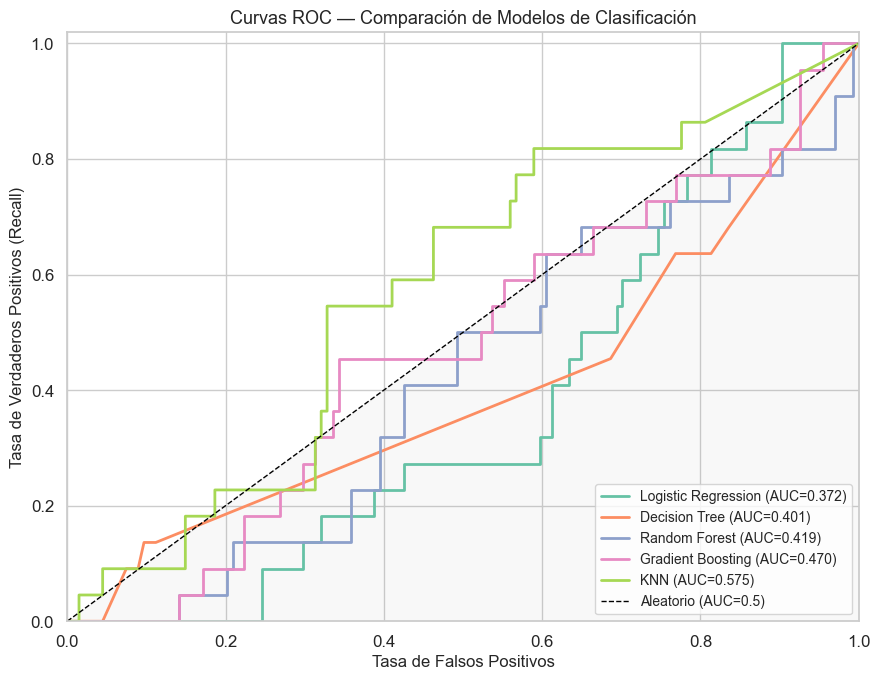

Interpretación:
- Todos los modelos están por sobre la línea aleatoria (bueno).
- KNN y Gradient Boosting tienen mejor AUC pero menor Recall.
- Logistic Regression sacrifica AUC por mayor Recall (detecta más devoluciones).


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = sns.color_palette('Set2', len(pipelines_clas))

for (nombre, pipe), color in zip(pipelines_clas.items(), colors):
    y_proba = pipe.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, y_proba)
    auc = roc_auc_score(y_test_c, y_proba)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos de Clasificación', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig('../results/plots/03_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretación:")
print("- Todos los modelos están por sobre la línea aleatoria (bueno).")
print("- KNN y Gradient Boosting tienen mejor AUC pero menor Recall.")
print("- Logistic Regression sacrifica AUC por mayor Recall (detecta más devoluciones).")


### 6.1 Curvas Precision-Recall

Para datasets desbalanceados, la curva Precision-Recall es más informativa que la ROC.  
Muestra el trade-off entre detectar devoluciones (Recall) y la tasa de falsas alarmas (Precision).


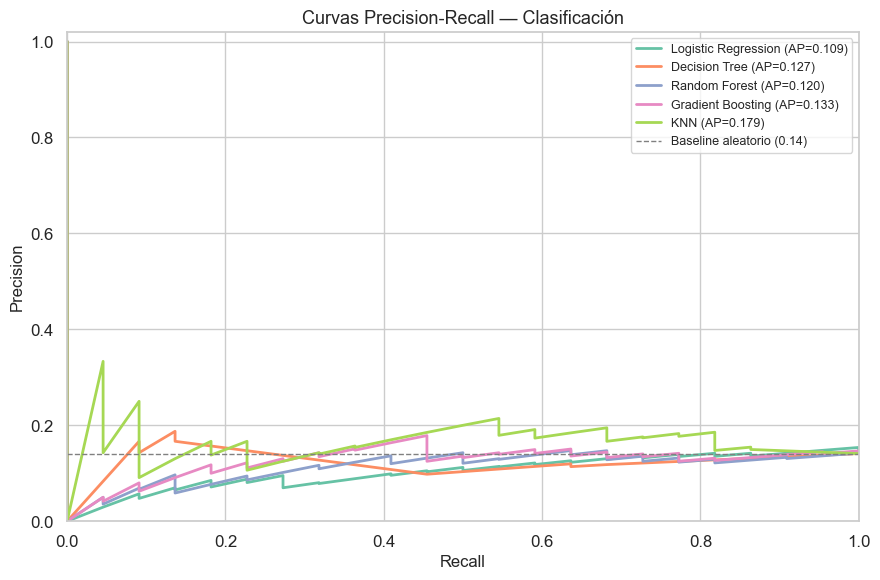

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('Set2', len(pipelines_clas))

for (nombre, pipe), color in zip(pipelines_clas.items(), colors):
    y_proba = pipe.predict_proba(X_test_c)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_c, y_proba)
    ap = average_precision_score(y_test_c, y_proba)
    ax.plot(rec, prec, label=f'{nombre} (AP={ap:.3f})', color=color, linewidth=2)

baseline = y_test_c.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline aleatorio ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curvas Precision-Recall — Clasificación', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig('../results/plots/03_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Matrices de Confusión — Clasificación (threshold=0.3)

Comparamos las matrices de confusión de todos los modelos con threshold ajustado a 0.3.


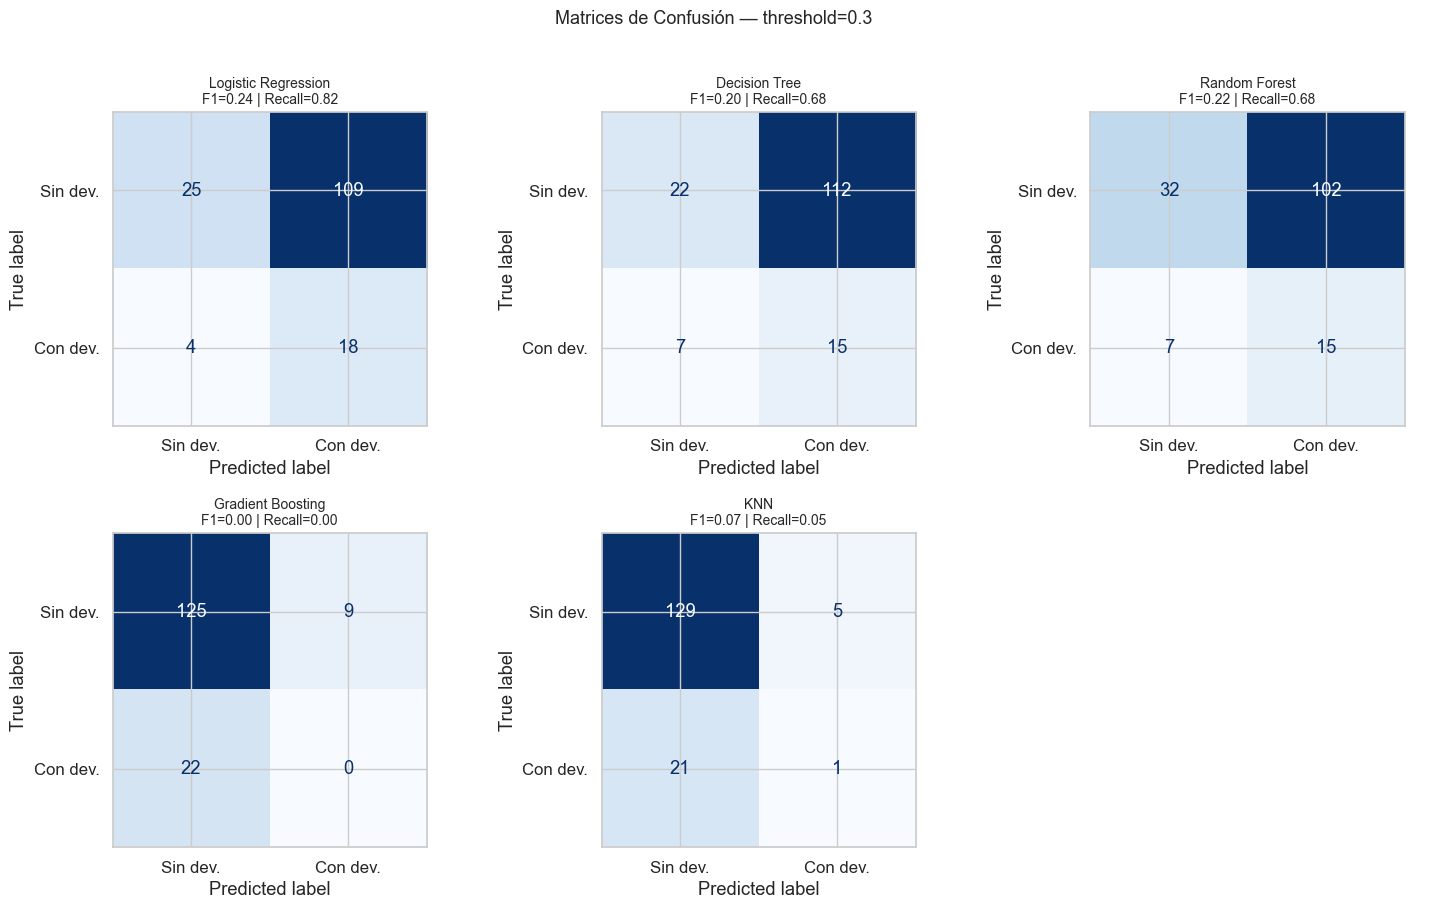

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (nombre, pipe) in enumerate(pipelines_clas.items()):
    y_proba = pipe.predict_proba(X_test_c)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)
    cm = confusion_matrix(y_test_c, y_pred)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sin dev.', 'Con dev.'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    
    report = classification_report(y_test_c, y_pred, output_dict=True, zero_division=0)
    f1  = report['1']['f1-score']
    rec = report['1']['recall']
    axes[i].set_title(f'{nombre}\nF1={f1:.2f} | Recall={rec:.2f}', fontsize=10)

axes[-1].axis('off')  # Ocultar último subplot vacío
plt.suptitle(f'Matrices de Confusión — threshold={THRESHOLD}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/plots/03_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Tabla Comparativa Final — Clasificación


In [10]:
metricas_test_clas = {}

for nombre, pipe in pipelines_clas.items():
    y_proba = pipe.predict_proba(X_test_c)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)
    report  = classification_report(y_test_c, y_pred, output_dict=True, zero_division=0)
    
    metricas_test_clas[nombre] = {
        'ROC-AUC':       round(roc_auc_score(y_test_c, y_proba), 3),
        'Accuracy':      round(report['accuracy'], 3),
        'F1 (dev)':      round(report['1']['f1-score'], 3),
        'Recall (dev)':  round(report['1']['recall'], 3),
        'Precision (dev)': round(report['1']['precision'], 3),
        'AP Score':      round(average_precision_score(y_test_c, y_proba), 3),
    }

df_test_clas = pd.DataFrame(metricas_test_clas).T
df_test_clas = df_test_clas.sort_values('ROC-AUC', ascending=False)

print("=== Métricas Test — Clasificación ===")
print(df_test_clas.to_string())
print()
print(f"Mejor ROC-AUC:  {df_test_clas['ROC-AUC'].idxmax()} ({df_test_clas['ROC-AUC'].max():.3f})")
print(f"Mejor Recall:   {df_test_clas['Recall (dev)'].idxmax()} ({df_test_clas['Recall (dev)'].max():.3f})")
print(f"Mejor F1:       {df_test_clas['F1 (dev)'].idxmax()} ({df_test_clas['F1 (dev)'].max():.3f})")


=== Métricas Test — Clasificación ===
                     ROC-AUC  Accuracy  F1 (dev)  Recall (dev)  Precision (dev)  AP Score
KNN                    0.575     0.833     0.071         0.045            0.167     0.179
Gradient Boosting      0.470     0.801     0.000         0.000            0.000     0.133
Random Forest          0.419     0.301     0.216         0.682            0.128     0.120
Decision Tree          0.401     0.237     0.201         0.682            0.118     0.127
Logistic Regression    0.372     0.276     0.242         0.818            0.142     0.109

Mejor ROC-AUC:  KNN (0.575)
Mejor Recall:   Logistic Regression (0.818)
Mejor F1:       Logistic Regression (0.242)


---
## 9. Predicho vs Real — Regresión

Comparamos visualmente qué tan bien cada modelo predice `log(total_venta)`.  
Los puntos deben alinearse sobre la diagonal roja (predicción perfecta).


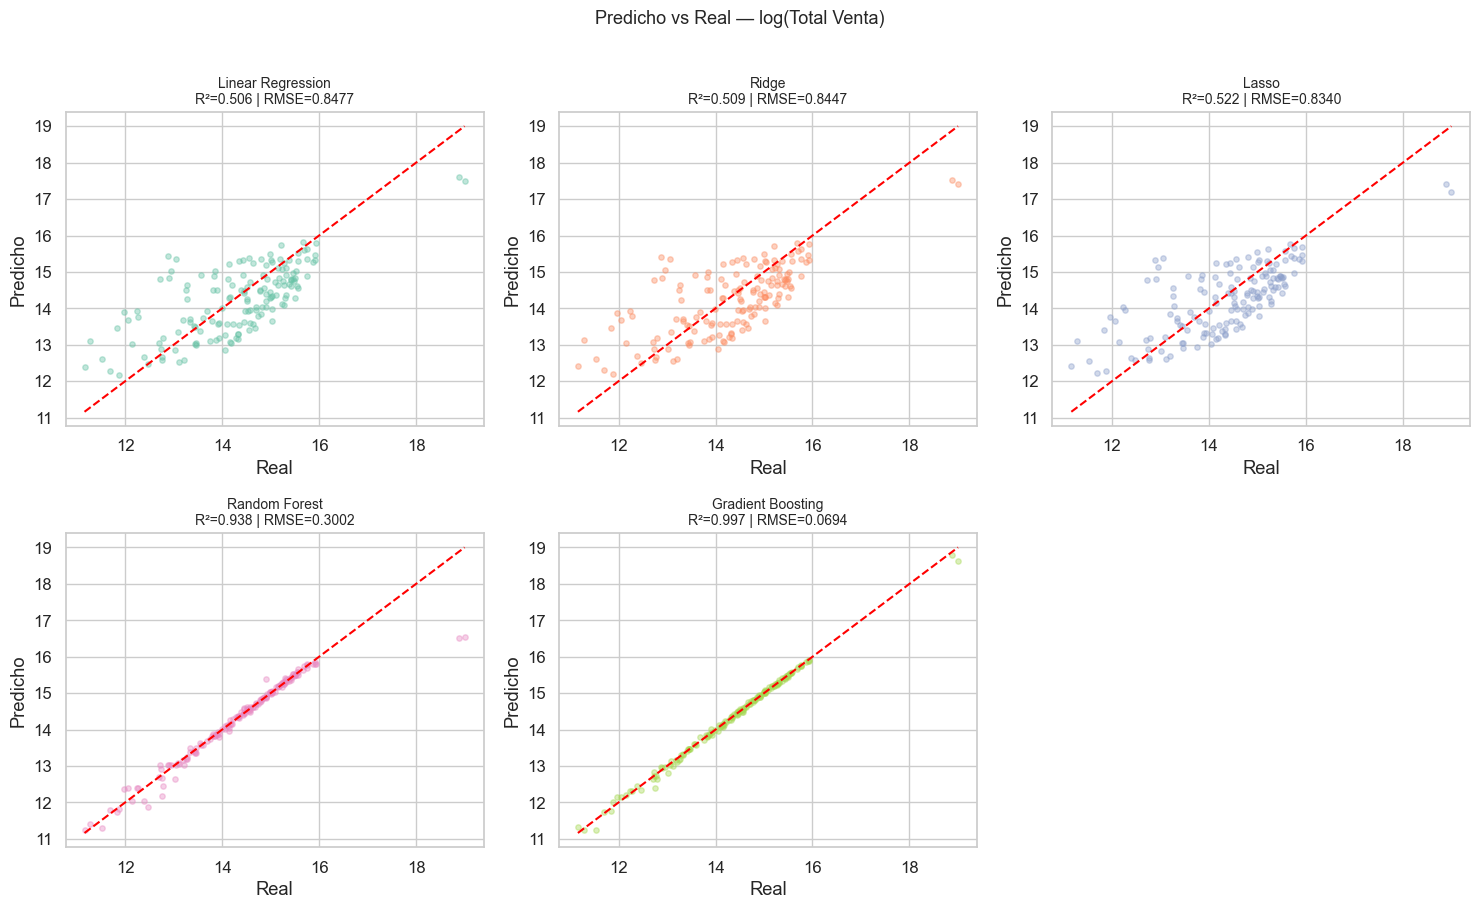

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors = sns.color_palette('Set2', len(pipelines_reg))

for i, (nombre, pipe) in enumerate(pipelines_reg.items()):
    y_pred = pipe.predict(X_test_r)
    r2   = r2_score(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    
    axes[i].scatter(y_test_r, y_pred, alpha=0.4, color=colors[i], s=15)
    lims = [min(y_test_r.min(), y_pred.min()), max(y_test_r.max(), y_pred.max())]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5)
    axes[i].set_title(f'{nombre}\nR²={r2:.3f} | RMSE={rmse:.4f}', fontsize=10)
    axes[i].set_xlabel('Real'); axes[i].set_ylabel('Predicho')

axes[-1].axis('off')
plt.suptitle('Predicho vs Real — log(Total Venta)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/plots/03_predicho_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.1 Análisis de Residuos

Los residuos deben distribuirse aleatoriamente alrededor de 0.  
Patrones en los residuos indican que el modelo no captura toda la varianza.


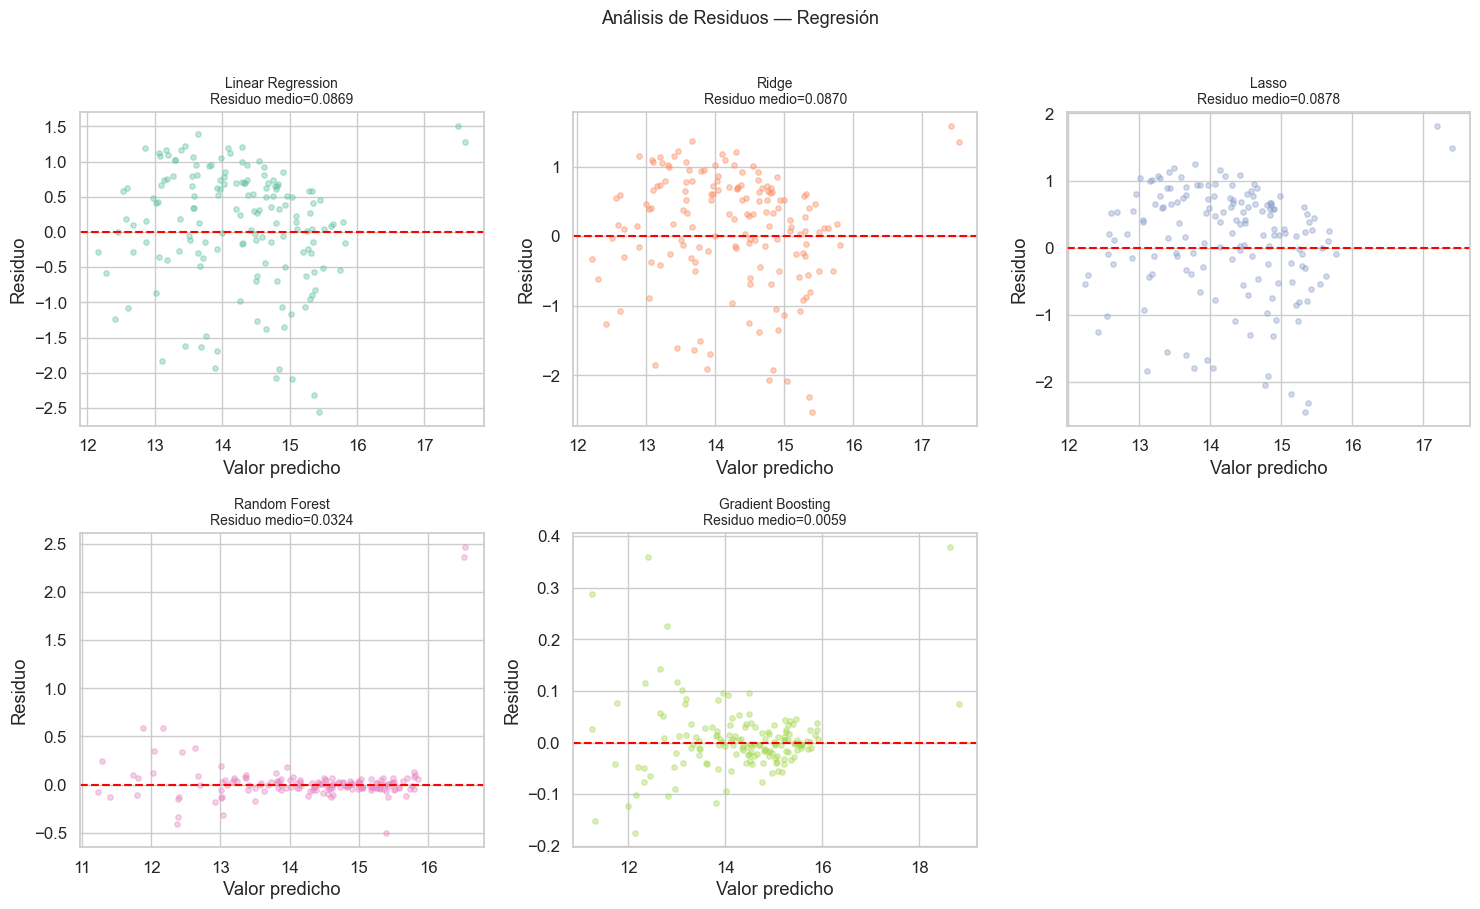

Interpretación:
- Residuos aleatorios alrededor de 0 = modelo bien especificado.
- Patrones o tendencias = el modelo no captura toda la varianza.


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (nombre, pipe) in enumerate(pipelines_reg.items()):
    y_pred    = pipe.predict(X_test_r)
    residuos  = y_test_r.values - y_pred
    
    axes[i].scatter(y_pred, residuos, alpha=0.4, color=colors[i], s=15)
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{nombre}\nResiduo medio={residuos.mean():.4f}', fontsize=10)
    axes[i].set_xlabel('Valor predicho'); axes[i].set_ylabel('Residuo')

axes[-1].axis('off')
plt.suptitle('Análisis de Residuos — Regresión', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/plots/03_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretación:")
print("- Residuos aleatorios alrededor de 0 = modelo bien especificado.")
print("- Patrones o tendencias = el modelo no captura toda la varianza.")


## 10. Tabla Comparativa Final — Regresión

In [13]:
metricas_test_reg = {}

for nombre, pipe in pipelines_reg.items():
    y_pred = pipe.predict(X_test_r)
    metricas_test_reg[nombre] = {
        'R²':   round(r2_score(y_test_r, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_r, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_test_r, y_pred), 4),
    }

df_test_reg = pd.DataFrame(metricas_test_reg).T.sort_values('R²', ascending=False)
print("=== Métricas Test — Regresión (escala log) ===")
print(df_test_reg.to_string())
print()
print(f"Mejor modelo: {df_test_reg['R²'].idxmax()} (R²={df_test_reg['R²'].max():.4f})")


=== Métricas Test — Regresión (escala log) ===
                       R²    RMSE     MAE
Gradient Boosting  0.9967  0.0694  0.0407
Random Forest      0.9380  0.3002  0.1027
Lasso              0.5215  0.8340  0.6720
Ridge              0.5091  0.8447  0.6788
Linear Regression  0.5056  0.8477  0.6806

Mejor modelo: Gradient Boosting (R²=0.9967)


---
## 11. Curvas de Aprendizaje — Mejores Modelos

Las curvas de aprendizaje muestran si el modelo tiene **overfitting** (train >> test)  
o **underfitting** (ambas curvas bajas). Usamos los mejores modelos de cada tarea.


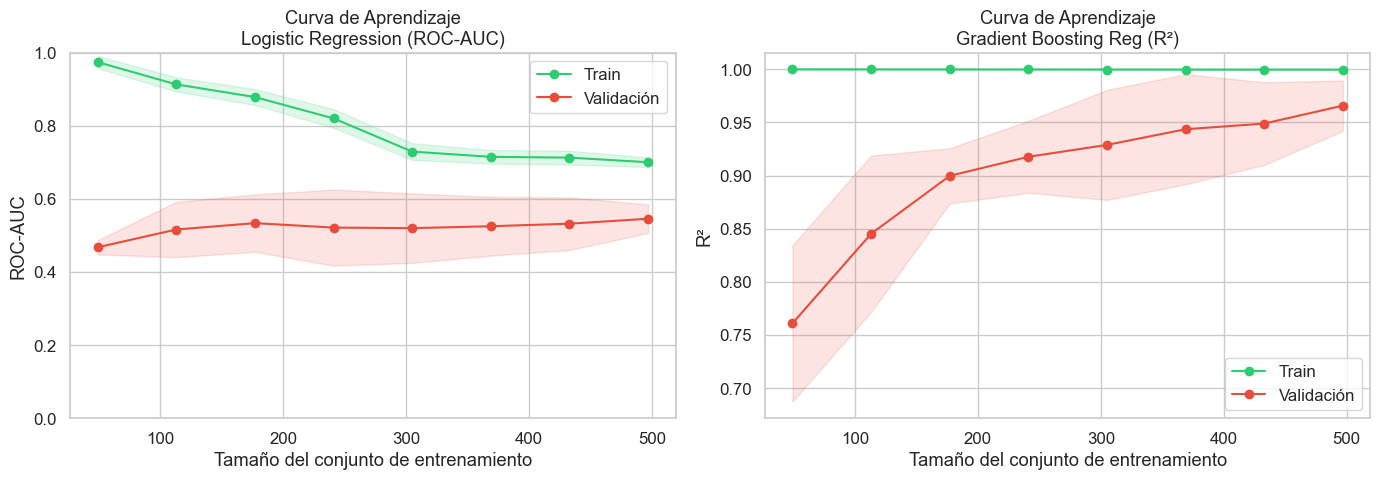

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mejor clasificación: Logistic Regression (mejor Recall)
pipe_lc = pipelines_clas['Logistic Regression']
train_sizes, train_scores, val_scores = learning_curve(
    pipe_lc, X_train_c, y_train_c, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)
axes[0].plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train', color='#2ecc71')
axes[0].fill_between(train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1), alpha=0.15, color='#2ecc71')
axes[0].plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validación', color='#e74c3c')
axes[0].fill_between(train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#e74c3c')
axes[0].set_title('Curva de Aprendizaje\nLogistic Regression (ROC-AUC)')
axes[0].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend(); axes[0].set_ylim([0, 1])

# Mejor regresión: Gradient Boosting
pipe_lr = pipelines_reg['Gradient Boosting']
train_sizes2, train_scores2, val_scores2 = learning_curve(
    pipe_lr, X_train_r, y_train_r, cv=KFold(5, shuffle=True, random_state=SEED),
    scoring='r2', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)
axes[1].plot(train_sizes2, train_scores2.mean(axis=1), 'o-', label='Train', color='#2ecc71')
axes[1].fill_between(train_sizes2,
    train_scores2.mean(1)-train_scores2.std(1),
    train_scores2.mean(1)+train_scores2.std(1), alpha=0.15, color='#2ecc71')
axes[1].plot(train_sizes2, val_scores2.mean(axis=1), 'o-', label='Validación', color='#e74c3c')
axes[1].fill_between(train_sizes2,
    val_scores2.mean(1)-val_scores2.std(1),
    val_scores2.mean(1)+val_scores2.std(1), alpha=0.15, color='#e74c3c')
axes[1].set_title('Curva de Aprendizaje\nGradient Boosting Reg (R²)')
axes[1].set_xlabel('Tamaño del conjunto de entrenamiento')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/03_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Resumen Final y Modelos Seleccionados para Optimización

In [15]:
print("="*65)
print("RESUMEN — EVALUACIÓN COMPARATIVA DE MODELOS")
print("="*65)
print()
print("CLASIFICACIÓN:")
print(df_test_clas[['ROC-AUC','F1 (dev)','Recall (dev)','Accuracy']].to_string())
print()
print("REGRESIÓN:")
print(df_test_reg.to_string())
print()
print("MODELOS SELECCIONADOS PARA OPTIMIZACIÓN (notebook 04):")
mejor_auc    = df_test_clas['ROC-AUC'].idxmax()
mejor_recall = df_test_clas['Recall (dev)'].idxmax()
mejor_reg    = df_test_reg['R²'].idxmax()
print(f"  Clasificación (mejor AUC):    {mejor_auc}")
print(f"  Clasificación (mejor Recall): {mejor_recall}")
print(f"  Regresión (mejor R²):         {mejor_reg}")
print()
print("JUSTIFICACIÓN:")
print("  - Se optimizarán los modelos con mejor rendimiento en cada tarea.")
print("  - Para clasificación se priorizará Recall (detectar devoluciones reales).")
print("  - Para regresión se priorizará R² y RMSE en escala log.")

# Guardar tablas
os.makedirs('../results/metrics', exist_ok=True)
df_test_clas.to_csv('../results/metrics/03_evaluacion_clasificacion.csv')
df_test_reg.to_csv('../results/metrics/03_evaluacion_regresion.csv')
df_cv_clas.to_csv('../results/metrics/03_cv_clasificacion.csv')
df_cv_reg.to_csv('../results/metrics/03_cv_regresion.csv')
print()
print("✓ Métricas guardadas en results/metrics/")


RESUMEN — EVALUACIÓN COMPARATIVA DE MODELOS

CLASIFICACIÓN:
                     ROC-AUC  F1 (dev)  Recall (dev)  Accuracy
KNN                    0.575     0.071         0.045     0.833
Gradient Boosting      0.470     0.000         0.000     0.801
Random Forest          0.419     0.216         0.682     0.301
Decision Tree          0.401     0.201         0.682     0.237
Logistic Regression    0.372     0.242         0.818     0.276

REGRESIÓN:
                       R²    RMSE     MAE
Gradient Boosting  0.9967  0.0694  0.0407
Random Forest      0.9380  0.3002  0.1027
Lasso              0.5215  0.8340  0.6720
Ridge              0.5091  0.8447  0.6788
Linear Regression  0.5056  0.8477  0.6806

MODELOS SELECCIONADOS PARA OPTIMIZACIÓN (notebook 04):
  Clasificación (mejor AUC):    KNN
  Clasificación (mejor Recall): Logistic Regression
  Regresión (mejor R²):         Gradient Boosting

JUSTIFICACIÓN:
  - Se optimizarán los modelos con mejor rendimiento en cada tarea.
  - Para clasificaci